Figure 2 B

In [4]:
# imports 
import numpy as np
import pandas as pd 
from scipy.stats import sem, ttest_rel, pearsonr, ttest_1samp, shapiro, levene, wilcoxon
from matplotlib import pyplot as plt

from functions import human_reliability, convert_to_deg

In [2]:
# load the human data 
s5x = np.load('data/s5x.npy')
s5y = np.load('data/s5y.npy')
s3x = np.load('data/s3x.npy')
s3y = np.load('data/s3y.npy')
s4x = np.load('data/s4x.npy')
s4y = np.load('data/s4y.npy')

In [5]:
# Convert the estimates to eccintricity space (i.e., degrees of visual angle)
human_im_size = 268.51895786308

s5x = convert_to_deg(s5x, human_im_size)
s3x = convert_to_deg(s3x, human_im_size)
s4x = convert_to_deg(s4x, human_im_size)

s5y = convert_to_deg(s5y, human_im_size)
s3y = convert_to_deg(s3y, human_im_size)
s4y = convert_to_deg(s4y, human_im_size)

In [7]:
# mean data across participants 
mean_s5x = np.nanmean(s5x,axis=1)
std_s5x = np.nanstd(s5x,axis=1)
sem_s5x = sem(s5x,axis=1)

mean_s5y = np.nanmean(s5y,axis=1)
std_s5y = np.nanstd(s5y,axis=1)

mean_s3x = np.nanmean(s3x,axis=1)
std_s3x = np.nanstd(s3x,axis=1)
sem_s3x = sem(s3x,axis=1)

mean_s3y = np.nanmean(s3y,axis=1)
std_s3y = np.nanstd(s3y,axis=1)

mean_s4x = np.nanmean(s4x,axis=1)
std_s4x = np.nanstd(s4x,axis=1)
sem_s4x = sem(s4x,axis=1)

mean_s4y = np.nanmean(s4y,axis=1)
std_s4y = np.nanstd(s4y,axis=1)

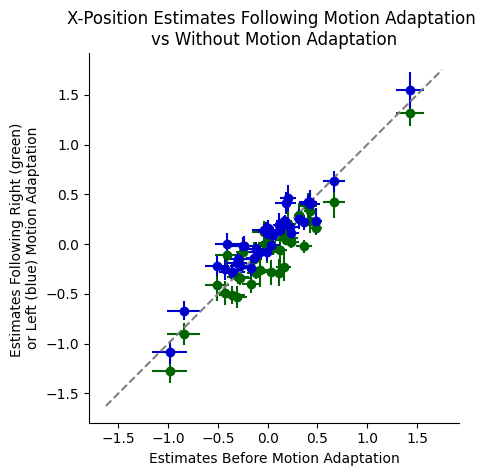

In [8]:
# estimates before and after motion adaptation for both directions 
pos_rangex = np.linspace(min(xpos),max(xpos))

plt.errorbar(mean_s5x,mean_s3x,yerr=sem_s3x,xerr=sem_s5x,fmt='o',color='darkgreen',label='Rightward Adapter')
plt.errorbar(mean_s5x,mean_s4x,yerr=sem_s4x,xerr=sem_s5x,fmt='o',color='mediumblue',label='Leftward Adapter')
plt.plot(pos_rangex,pos_rangex,color='grey',linestyle='--')
plt.title('X-Position Estimates Following Motion Adaptation \nvs Without Motion Adaptation')
plt.xlabel('Estimates Before Motion Adaptation')
plt.ylabel('Estimates Following Right (green) \nor Left (blue) Motion Adaptation')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
x0, x1 = plt.gca().get_xlim()
y0, y1 = plt.gca().get_ylim()
plt.gca().set_aspect(abs(x1 - x0) / abs(y1 - y0)) 

# plt.savefig('/home/eyakub/scratch/scatter.eps', format='eps', bbox_inches='tight')